# FIGO-based CTG analysis

This notebook provides a practical demonstration of the automatic CTG analysis
presented in **Automated cardiotocography interpretation based on international guidelines for intrapartum fetal hypoxia detection**. It illustrates the workflow from the original
CTG recordings to the final FIGO-based classification.

A detailed description of the methodology, implemented criteria, and experimental
evaluation is provided in:

> **[Alonso S., López D., Álvaro L., Mejía I., Fernández-Pascual A., Alaíz C]. [Automated cardiotocography interpretation based on international guidelines for intrapartum fetal hypoxia detection]. [JOURNAL, 2026]. [DOI/LINK]**


### Imports and repository setup

Run this notebook from the repository root. Adapt the import below only if the `CTG` class is exposed from a different module in your repository.


In [24]:
%load_ext autoreload
%autoreload 2

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.df_ctg import DF_CTG

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Load the data

The CTG dataset is loaded, including the fetal heart rate (FHR) and uterine contraction (UC) signals required for the analysis.

In [27]:
df_FIGO = DF_CTG(config_file='config/config.jsonc')
df_FIGO.read_ctgs_from_files()

Reading Completed:  552 ctg created


### Original CTG recording

A single CTG recording is selected to illustrate the complete analysis pipeline.
The original FHR and UC signals are shown below before preprocessing.

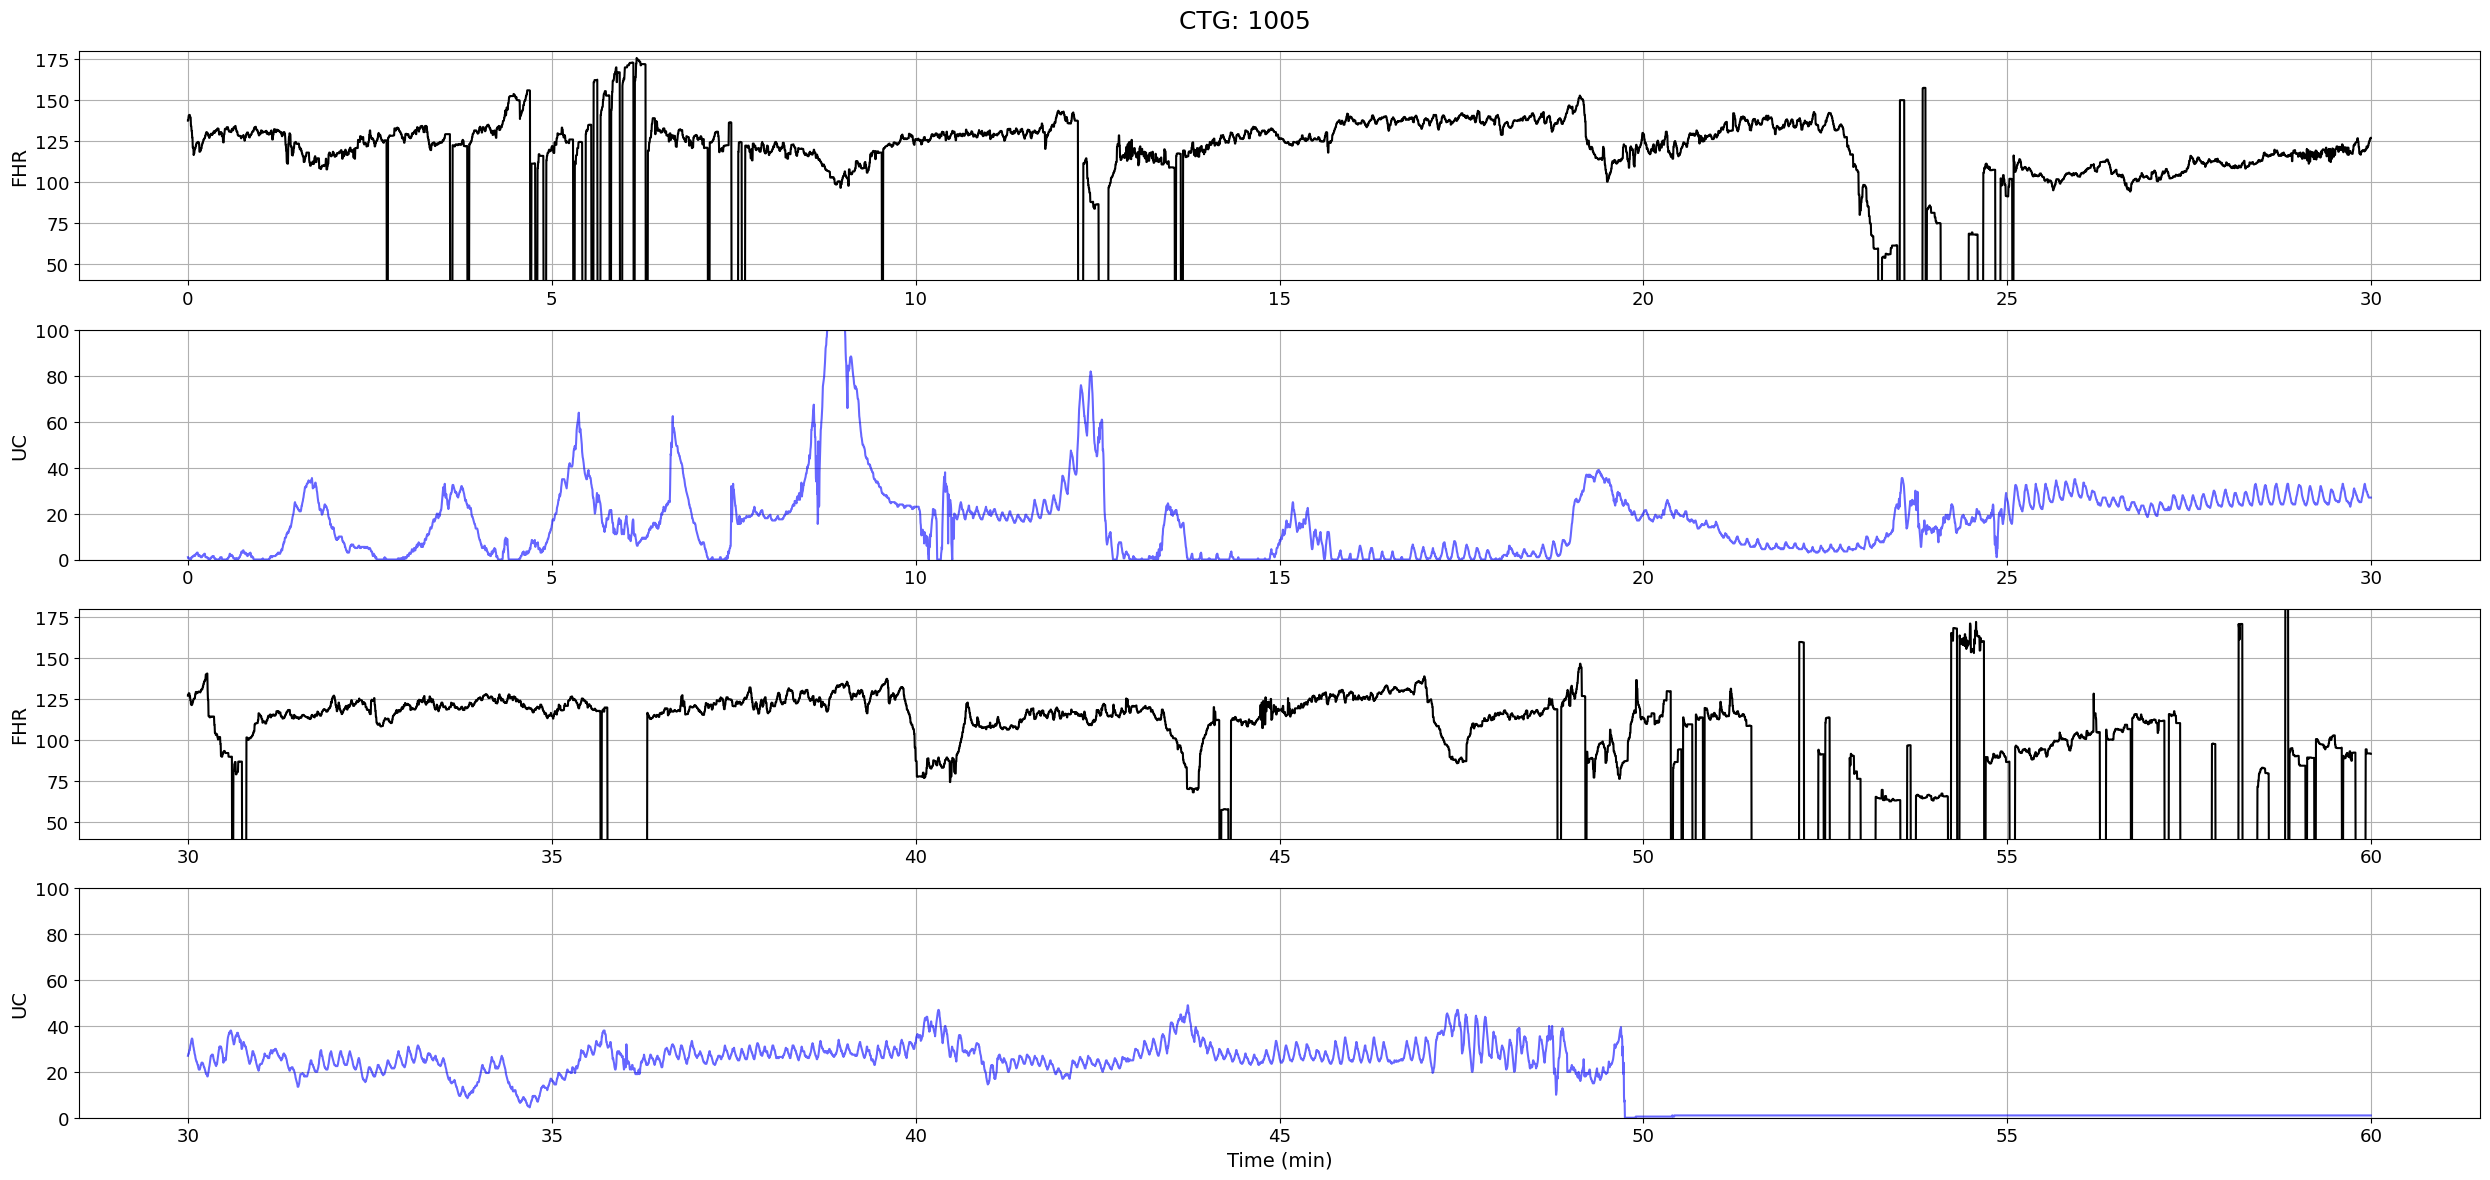

In [28]:
example_ctg = df_FIGO.ctgs[4]
example_ctg.plot_ctg()

### Signal preprocessing

The CTG signals are preprocessed before applying the rule-based analysis.
Invalid signal values and missing-data intervals are handled, and the recording is restricted to the interval considered for the analysis.

In [29]:
df_FIGO.preprocess_ctgs()

SPLINES preprocessing completed: 0/552 skipped as invalid (id= [])


### Preprocessed CTG recording

The same recording is shown after preprocessing. These FHR and UC signals constitute the input to the subsequent FIGO-based analysis.

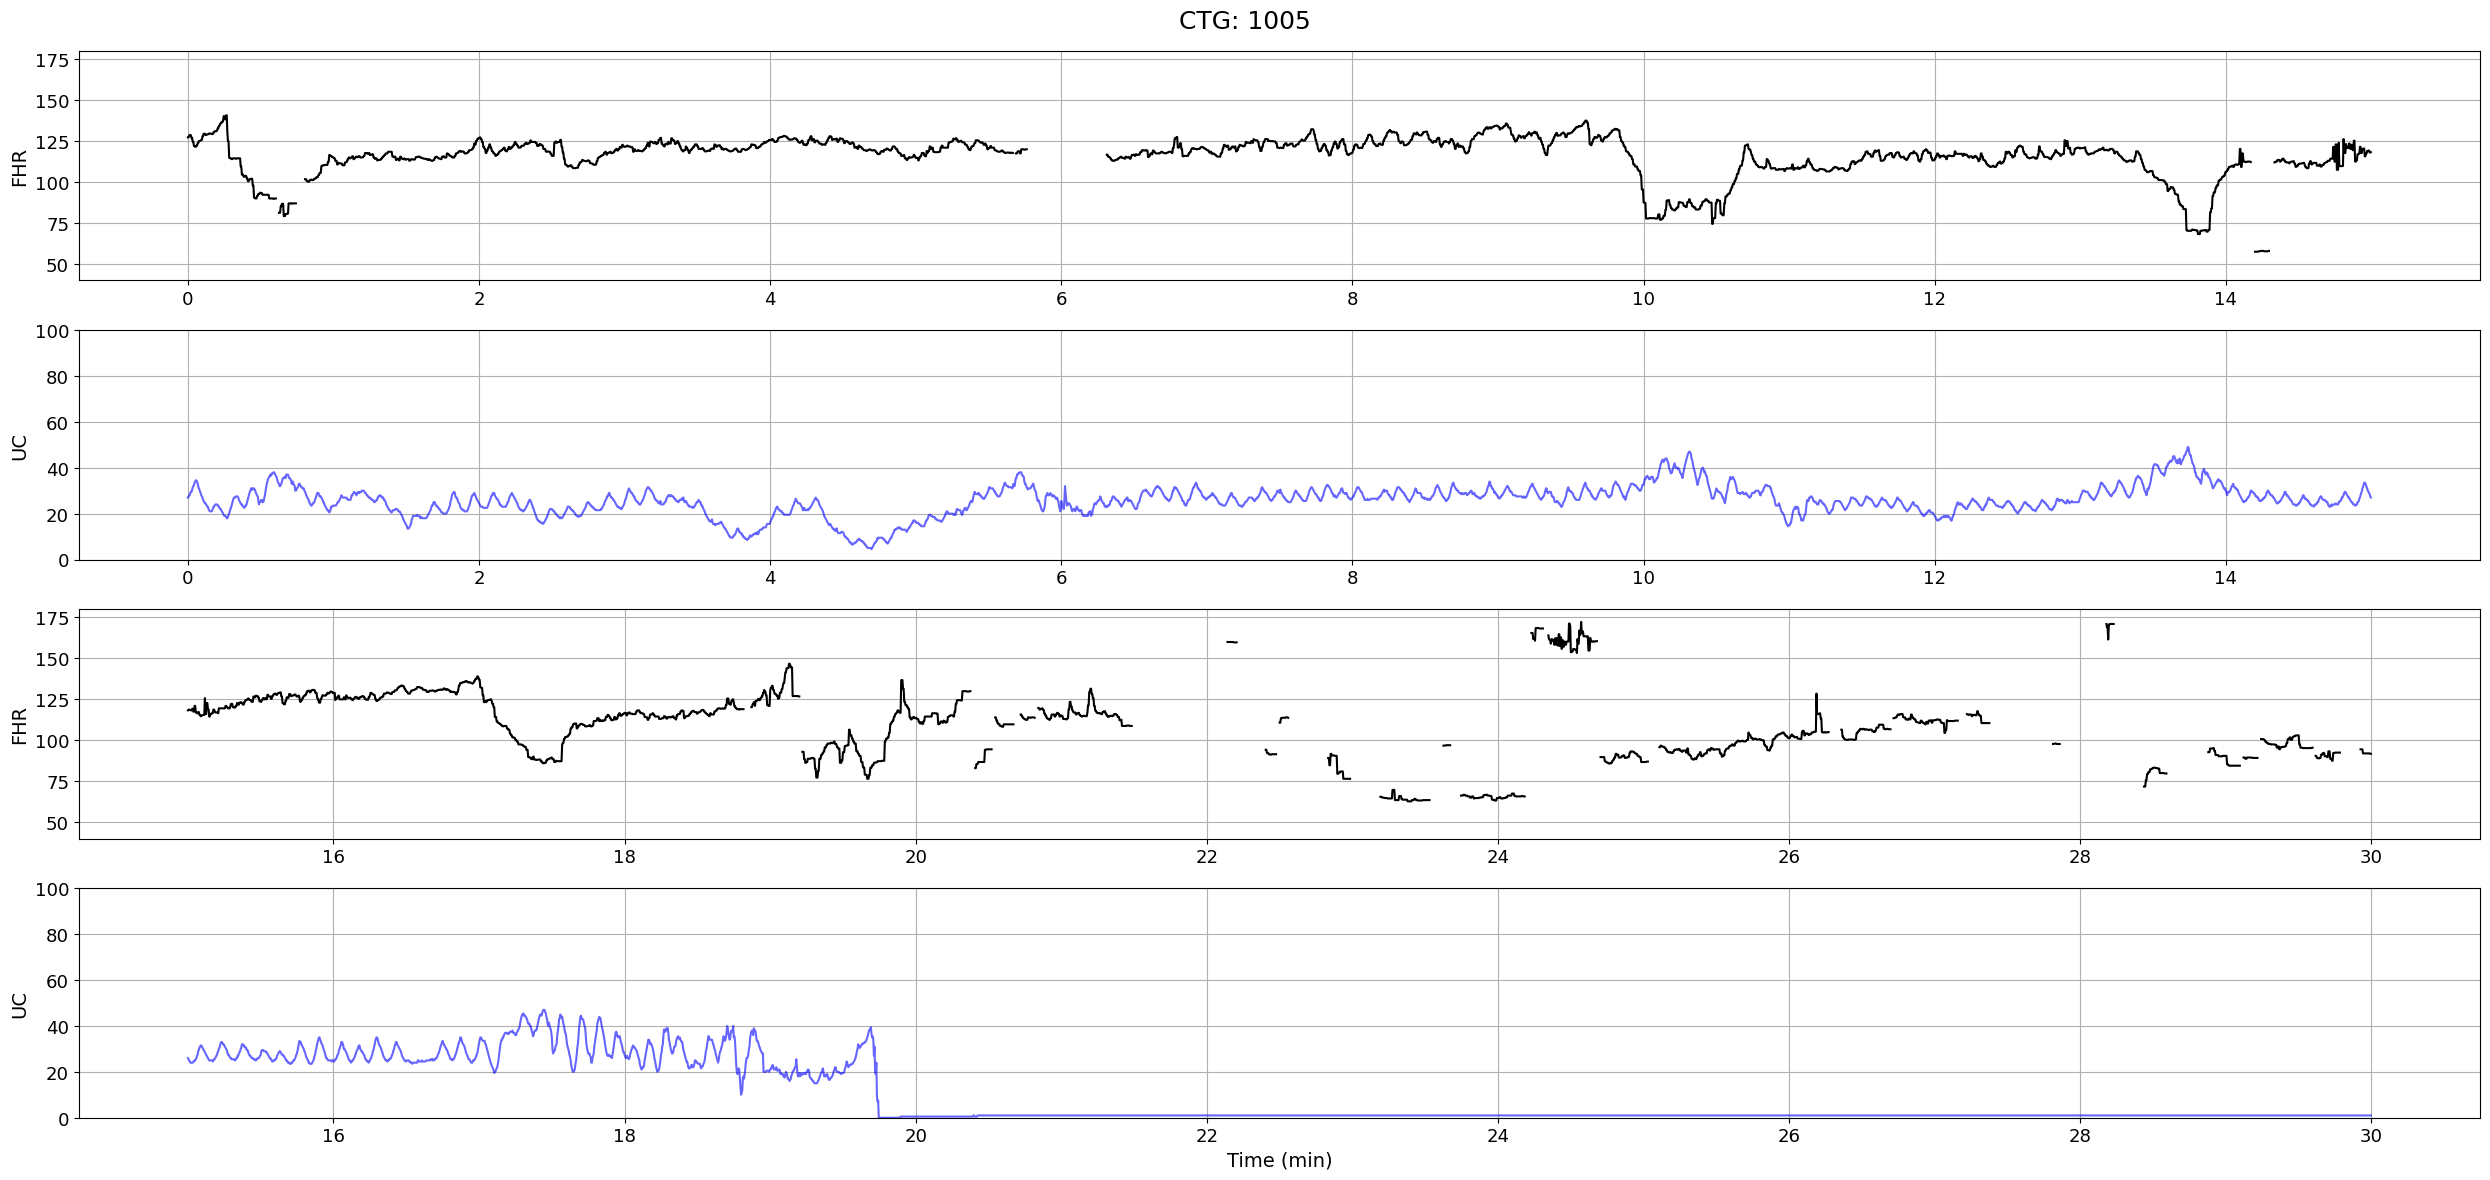

In [30]:
example_ctg = df_FIGO.ctgs[4]
example_ctg.plot_ctg()

### FIGO feature analysis

The FIGO-based analysis is first applied to the selected CTG recording to illustrate the different components of the method.

The system evaluates the FHR baseline, decelerations, and variability. Uterine contractions are also detected and used to assess their temporal relationship with FHR decelerations. The resulting feature classifications are then combined to obtain the overall CTG classification.

The following outputs allow each stage of the analysis to be inspected individually. The complete definition of the implemented criteria is provided in the accompanying article.

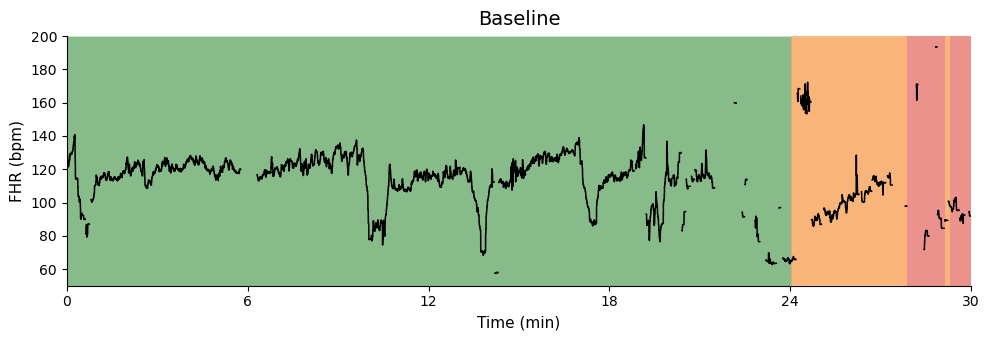

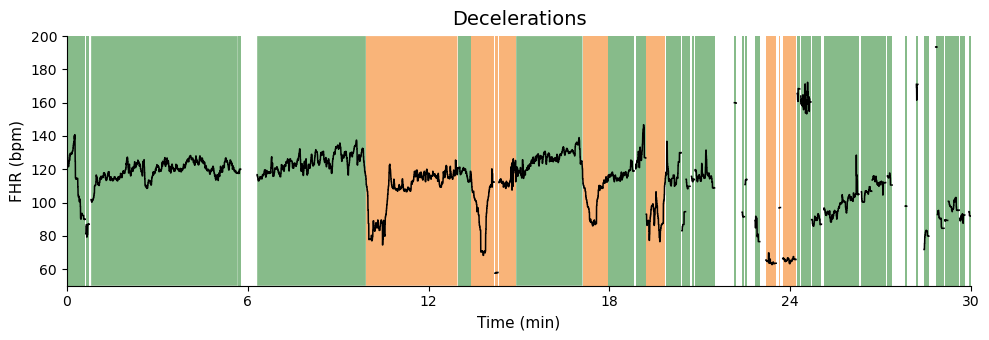

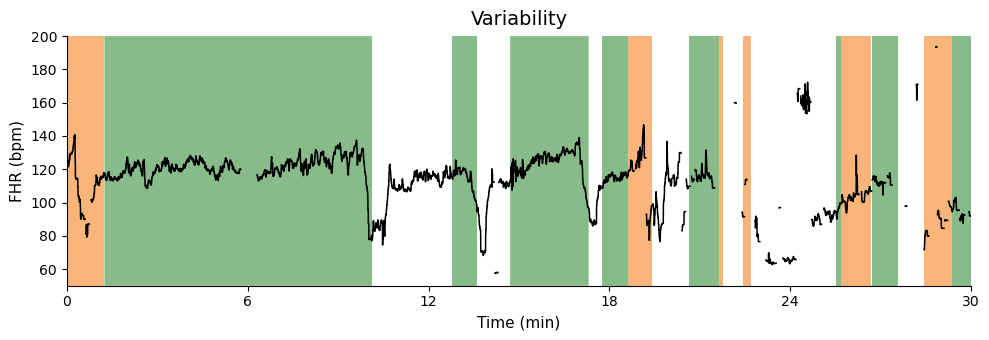

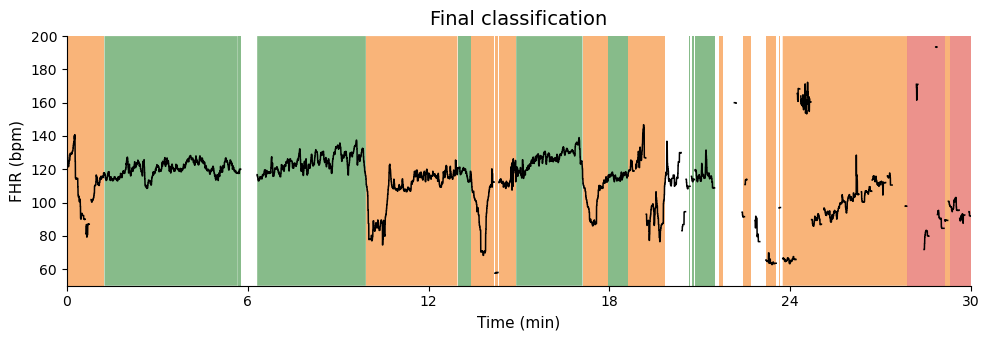

In [49]:
_ = example_ctg.apply_rules(center=True, baseline_graph=True, variability_graph=True, deceleration_graph=True, rules_type="FIGO")
# print(f"Risk Level: {example_ctg.}")

### Analysis of the complete dataset

After illustrating the procedure on a single CTG, the same preprocessing and
FIGO-based analysis are applied to all recordings in the dataset.

For each CTG, the system evaluates baseline, decelerations, and variability and
combines their corresponding categories to obtain the final classification.
These results can then be used for the dataset-level evaluation of the method
reported in the article.

552/552 

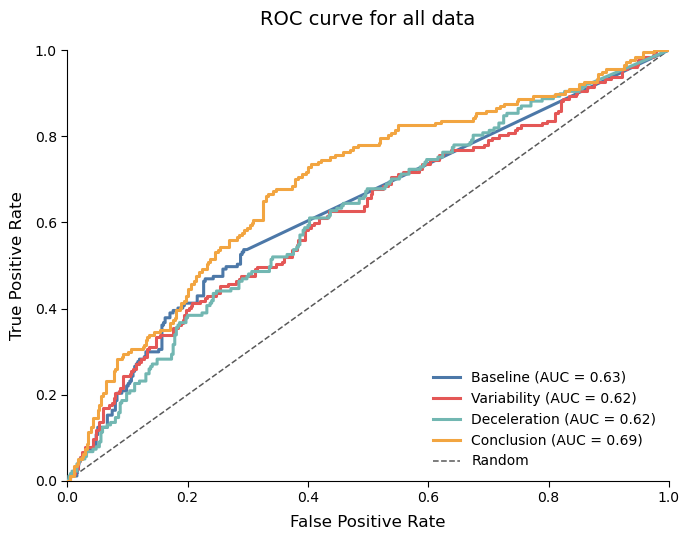

In [48]:
df_FIGO.get_roc_curves(title="ROC curve for all data")